## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [ ]:
sns.set(style = "whitegrid")

In [3]:
df = pd.read_csv("AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [8]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.shape
# 6 Juta row, 11 kolom jir

(6362620, 11)

In [10]:
# Fraud = 0.13% dari seluruh transaksi (1 : 774), BUKAN 13%.
# Konsekuensi: tebak-semua-nol sudah akurat 99.87%, jadi akurasi bukan metrik yang valid di sini.
round(df["isFraud"].value_counts()[1] / df.shape[0] * 100, 2)

np.float64(0.13)

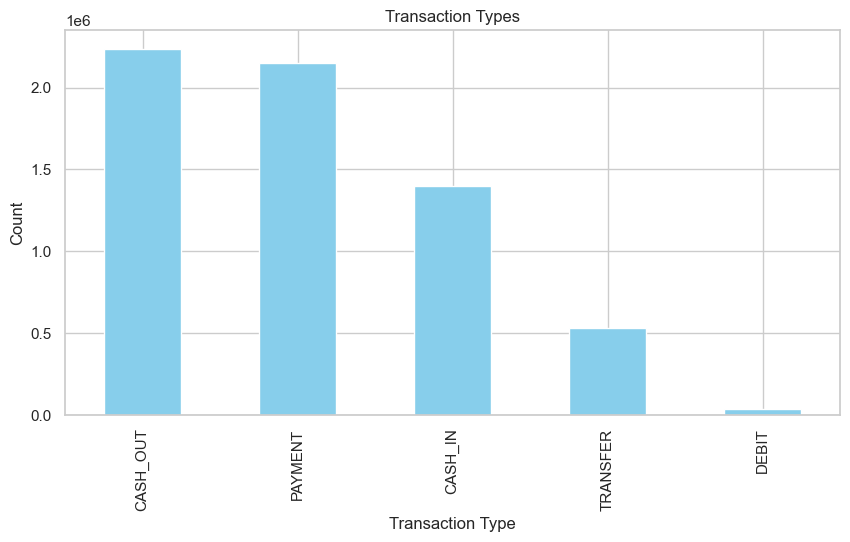

In [11]:
df["type"].value_counts().plot(kind = "bar",title = "Transaction Types", color = "skyblue", figsize = (10, 5))
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

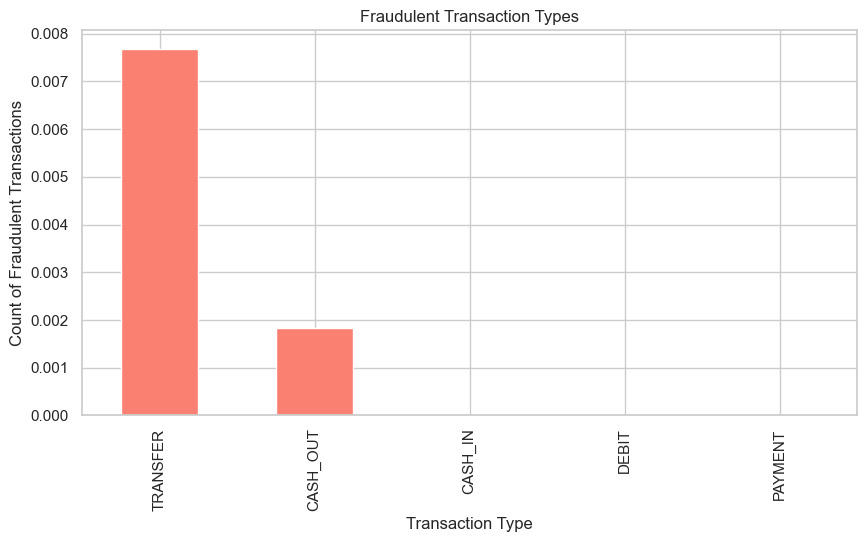

In [12]:
fraud_types = df.groupby("type")["isFraud"].mean().sort_values(ascending = False)
fraud_types.plot(kind = "bar", title = "Fraudulent Transaction Types", color = "salmon", figsize = (10, 5))
plt.xlabel("Transaction Type")
plt.ylabel("Count of Fraudulent Transactions")
plt.show()

In [13]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

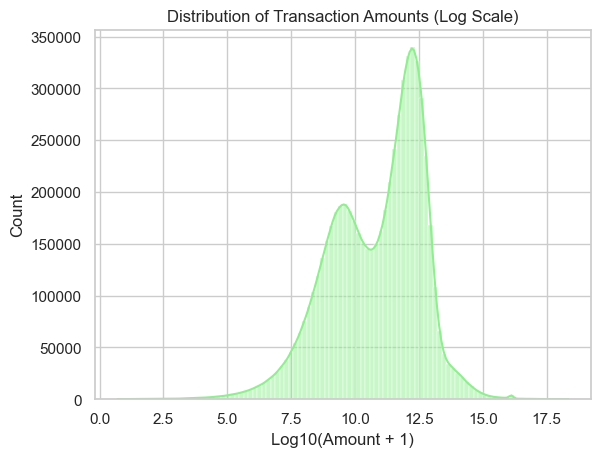

In [14]:
sns.histplot(np.log1p(df["amount"] + 1), bins = 100, kde =True, color = "lightgreen")
plt.title("Distribution of Transaction Amounts (Log Scale)")
plt.xlabel("Log10(Amount + 1)")
plt.ylabel("Count")
plt.show()

In [ ]:
sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y = "amount", hue = "isFraud", legend = False, palette = "Set2")
plt.title("Boxplot of Transaction Amounts by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")
plt.show()

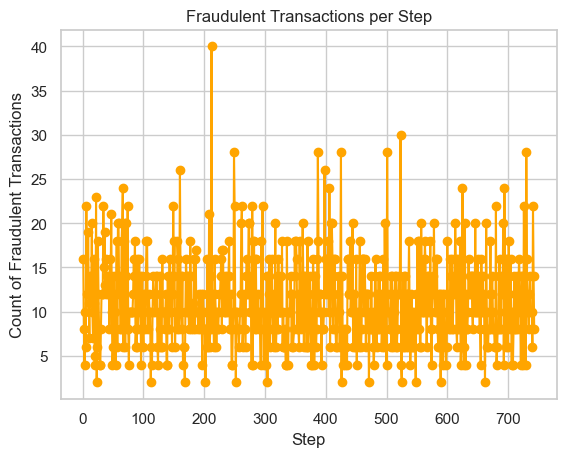

In [19]:
fraud_per_step = df[df["isFraud"] == 1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values, marker = "o", color = "orange", label = "Fraudulent Transactions" )
plt.title("Fraudulent Transactions per Step")
plt.xlabel("Step")
plt.ylabel("Count of Fraudulent Transactions")
plt.show()

In [20]:
# ponytail: `step` sengaja dipertahankan — time-based split di bawah butuh kolom ini.
# `step` tidak pernah sampai ke model: ColumnTransformer hanya menyebut fitur yang
# dipakai dan membuang sisanya lewat remainder="drop".

In [ ]:
df.head()

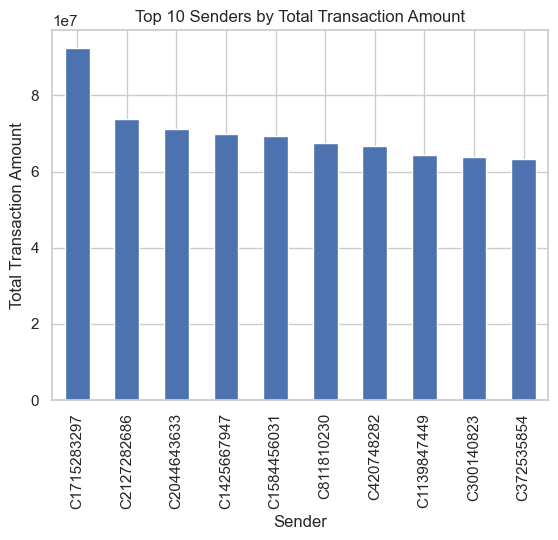

In [22]:
top_senders = df.groupby("nameOrig")["amount"].sum().sort_values(ascending = False).head(10)
top_senders.plot(kind="bar", title="Top 10 Senders by Total Transaction Amount")
plt.xlabel("Sender")
plt.ylabel("Total Transaction Amount")
plt.show()

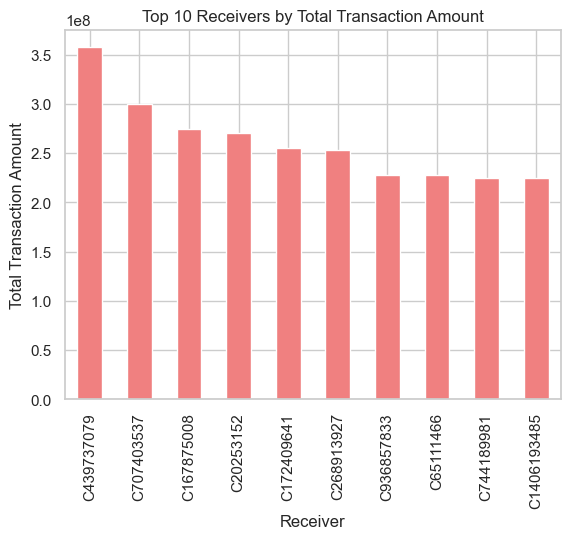

In [23]:
top_receivers = df.groupby("nameDest")["amount"].sum().sort_values(ascending = False).head(10)
top_receivers.plot(kind="bar", title="Top 10 Receivers by Total Transaction Amount", color = "lightcoral")
plt.xlabel("Receiver")
plt.ylabel("Total Transaction Amount")
plt.show()

In [ ]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
sns.countplot(data = fraud_types, x = "type", hue = "isFraud", palette = "Set1")
plt.title("Fraudulent Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(title = "Fraud Status", loc = "upper right")
plt.show()

In [25]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

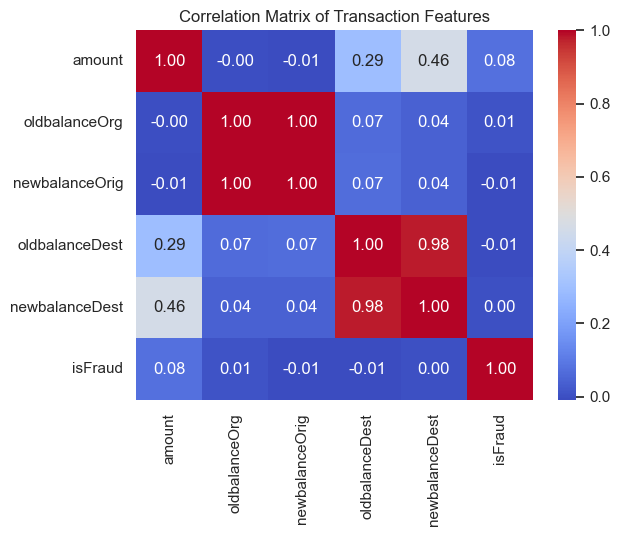

In [27]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix of Transaction Features")
plt.show()

In [28]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]
len(zero_after_transfer)

1188074

In [ ]:
zero_after_transfer.head()

## Feature Engineering and Model Training

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [32]:
df_model = df.drop(columns = ["nameOrig", "nameDest", "isFlaggedFraud"])

In [ ]:
df_model.head()

In [34]:
categorical_features = ["type"]
numerical_features = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [36]:
# ponytail: time-based split, menutup dua kebocoran sekaligus.
#  1) Pasangan fraud TRANSFER/CASH_OUT punya `step` dan `amount` identik
#     (4000 dari 4080 pasangan; oldbalanceOrg/newbalanceOrig sama persis di 98.4%).
#     Random split membelah 1665 pasangan ke sisi berlawanan -> model menghafal kembarannya.
#     Split by time tidak pernah membelah pasangan karena `step`-nya sama.
#  2) Random split memasukkan transaksi masa depan ke train (look-ahead bias),
#     padahal fraud rate bergerak 4.8x antar kuartil waktu.
cutoff = df_model["step"].quantile(0.7)
train = df_model[df_model["step"] <= cutoff]
test = df_model[df_model["step"] > cutoff]

X_train, y_train = train.drop(columns="isFraud"), train["isFraud"]
X_test, y_test = test.drop(columns="isFraud"), test["isFraud"]

assert y_train.sum() > 0 and y_test.sum() > 0, "ada split tanpa fraud"
assert X_train["step"].max() < X_test["step"].min(), "split tumpang tindih di waktu"
print(f"train {len(X_train):,} baris ({y_train.sum()} fraud) | test {len(X_test):,} baris ({y_test.sum()} fraud)")

train 4,463,587 baris (3643 fraud) | test 1,899,033 baris (4570 fraud)


In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder = "drop"
)

In [38]:
pipelines = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight = "balanced", random_state = 42, max_iter = 1000))
])

In [39]:
pipelines.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [40]:
y_pred = pipelines.predict(X_test)

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1894463
           1       0.05      0.97      0.09      4570

    accuracy                           0.95   1899033
   macro avg       0.52      0.96      0.53   1899033
weighted avg       1.00      0.95      0.97   1899033



In [42]:
confusion_mat = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_mat)

Confusion Matrix:
 [[1804541   89922]
 [    146    4424]]


In [43]:
# Akurasi dibuang: baseline tebak-semua-nol sudah 99.87%, jadi angka itu tidak berarti.
proba = pipelines.predict_proba(X_test)[:, 1]
print("PR-AUC  :", round(average_precision_score(y_test, proba), 4))
print("baseline:", round(y_test.mean(), 6), "(fraud rate — ini yang harus dikalahkan)")

# ponytail: ambil threshold dengan F1 terbaik dari PR curve.
# Ganti dengan aturan berbasis biaya begitu biaya 1 false positive vs 1 fraud lolos diketahui.
prec, rec, thr = precision_recall_curve(y_test, proba)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = f1[:-1].argmax()
print(f"threshold terbaik: {thr[best]:.4f}  precision={prec[best]:.3f}  recall={rec[best]:.3f}")
print(classification_report(y_test, proba >= thr[best], digits=3))

PR-AUC  : 0.6744
baseline: 0.002406 (fraud rate — ini yang harus dikalahkan)
threshold terbaik: 0.9926  precision=0.771  recall=0.539
              precision    recall  f1-score   support

           0      0.999     1.000     0.999   1894463
           1      0.771     0.539     0.635      4570

    accuracy                          0.999   1899033
   macro avg      0.885     0.769     0.817   1899033
weighted avg      0.998     0.999     0.998   1899033



In [ ]:
# Ekspor kurva PR untuk app Streamlit. Tanpa ini, chart di app jadi basi begitu
# model dilatih ulang.
# Sampling rata di ruang recall: kurva tetap mulus, dan titik threshold justru
# jadi rapat di wilayah 0.9-1.0 tempat seluruh trade-off terjadi.
p, r, t = prec[:-1], rec[:-1], thr
order = np.argsort(r)
p, r, t = p[order], r[order], t[order]
anchor = int(np.where(order == best)[0][0])

keep = np.unique(np.append(np.searchsorted(r, np.linspace(r.min(), r.max(), 400)), anchor))
keep = keep[keep < len(r)]

pd.DataFrame({"threshold": t[keep].round(6),
              "precision": p[keep].round(5),
              "recall": r[keep].round(5)}).to_csv("pr_curve.csv", index=False)
print(f"pr_curve.csv: {len(thr):,} titik -> {len(keep)}")

In [ ]:
# Learning curve: apakah menambah data masih menaikkan performa?
# Subsample ACAK di dalam jendela latih, bukan potongan paling awal. Tiap subset
# menutupi rentang waktu yang sama, jadi yang diukur murni banyaknya data, bukan
# seberapa jauh dari periode uji. Dinilai di test set yang sama dan tetap.
lc = []
for frac in [0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1.0]:
    sub = train if frac == 1.0 else train.sample(frac=frac, random_state=42)
    Xs, ys = sub.drop(columns="isFraud"), sub["isFraud"]

    # handle_unknown="ignore" khusus di sini: subsample 1% bisa saja tidak memuat
    # DEBIT, dan tanpa ini transform di test set akan error.
    step = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(transformers=[
            ("num", StandardScaler(), numerical_features),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ], remainder="drop")),
        ("model", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)),
    ]).fit(Xs, ys)

    lc.append({"rows": len(sub), "fraud": int(ys.sum()),
               "train_pr_auc": round(average_precision_score(ys, step.predict_proba(Xs)[:, 1]), 5),
               "test_pr_auc": round(average_precision_score(y_test, step.predict_proba(X_test)[:, 1]), 5)})
    print(f"  {len(sub):>9,} baris ({ys.sum():>4} fraud)  test PR-AUC {lc[-1]['test_pr_auc']:.4f}")

pd.DataFrame(lc).to_csv("learning_curve.csv", index=False)
print("learning_curve.csv ditulis")

In [ ]:
# Contoh transaksi untuk tombol di app. Diambil dari periode UJI saja, jadi tak
# satu pun baris ini pernah dilatihkan ke model yang menilainya.
# Sampel acak apa adanya, tidak dipilih yang mudah ditangkap: app menampilkan
# label asli di samping prediksi, jadi fraud yang lolos justru memperlihatkan
# arti recall 0.539 secara konkret.
ex_cols = ["type", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
examples = pd.concat([
    test[test["isFraud"] == 1].sample(40, random_state=42),
    test[test["isFraud"] == 0].sample(40, random_state=42),
])[ex_cols + ["isFraud"]].reset_index(drop=True)
examples.to_csv("examples.csv", index=False)

hit = (pipelines.predict_proba(examples[ex_cols])[:, 1] >= thr[best])
print(f"examples.csv: {int(hit[:40].sum())}/40 fraud tertangkap, "
      f"{int(hit[40:].sum())}/40 sah salah tuduh")

## Export Model

In [44]:
import joblib

# Export Model
joblib.dump(pipelines, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']